Import Libraries

In [1]:
import sys
from pathlib import Path

# Project root directory
project_root = Path().resolve().parent

# Add project root to Python path
sys.path.append(str(project_root))

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from src.config import RAW_DATA_PATH
from src.data_loader import load_data

Load Dataset

In [3]:
df = load_data(RAW_DATA_PATH)

✅ Dataset loaded successfully.


In [4]:
df.head()
df.shape
df.columns
df.dtypes
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dt.day_name()
# df.info()
df.shape
df.isnull().sum()
# df["City"].nunique()
df["City"].unique

<bound method Series.unique of 0            Ahmedabad
1            Ahmedabad
2            Ahmedabad
3            Ahmedabad
4            Ahmedabad
             ...      
29526    Visakhapatnam
29527    Visakhapatnam
29528    Visakhapatnam
29529    Visakhapatnam
29530    Visakhapatnam
Name: City, Length: 29531, dtype: str>

# Day 3 - Data Cleaning

## Step 1: Missing Value Analysis

array([[<Axes: title={'center': 'PM2.5'}>,
        <Axes: title={'center': 'PM10'}>],
       [<Axes: title={'center': 'CO'}>,
        <Axes: title={'center': 'Xylene'}>]], dtype=object)

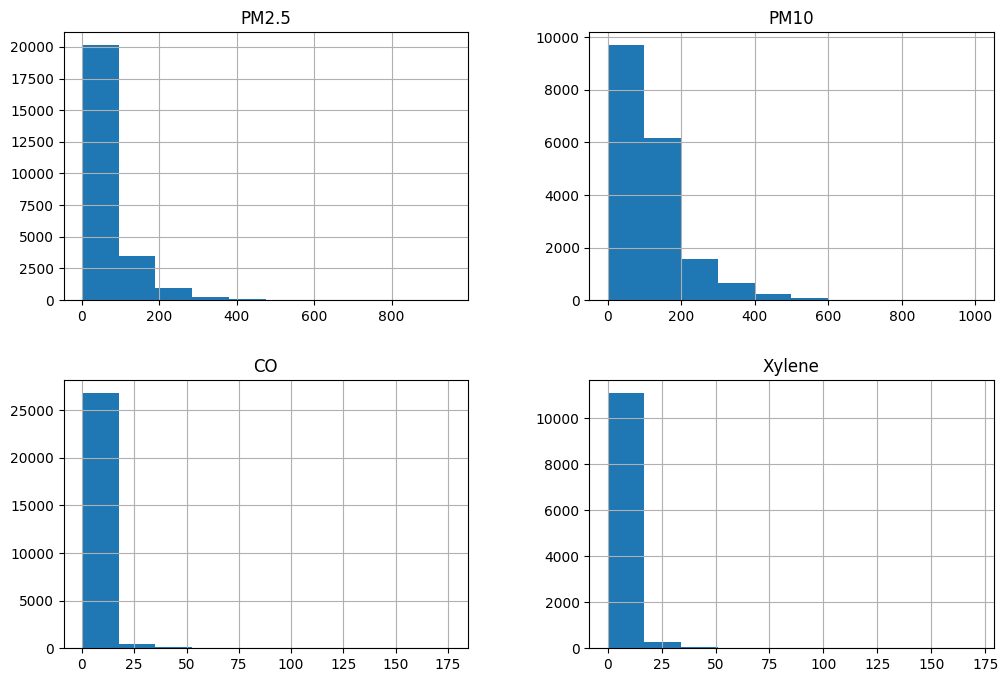

In [5]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = (
    pd.DataFrame({
        "Missing Values": missing_values,
        "Missing Percentage": missing_percentage
    })
    .sort_values(by="Missing Percentage", ascending=False)
)

missing_df
df[["PM2.5", "PM10", "CO", "Xylene"]].describe().T
df[["PM2.5", "PM10", "CO", "Xylene"]].hist(figsize=(12, 8))



In [6]:
# Remove rows where target variables are missing
df = df.dropna(subset=["AQI", "AQI_Bucket"])

print("New Shape:", df.shape)

New Shape: (24850, 16)


In [7]:
df.corr(numeric_only=True)["AQI"].sort_values(ascending=False)

AQI        1.000000
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64

Observation:

Xylene has 61.32% missing values, making it the most incomplete feature in the dataset.
It also shows a weak correlation (0.1655) with the target variable (AQI).
Since a large portion of the column would require imputation, it could distort the original feature distribution without providing significant predictive value.
Therefore, Xylene is a suitable candidate for removal.

In [8]:
# drop Xylene column 
df = df.drop(columns=["Xylene"])

print(df.shape)

(24850, 15)


We removed the Xylene feature from the dataset. The number of rows remained the same because only a column was removed. The dataset now contains 24,850 observations and 15 features.

In [9]:
df.isnull().sum()

City             0
Date             0
PM2.5          678
PM10          7086
NO             387
NO2            391
NOx           1857
NH3           6536
CO             445
SO2            605
O3             807
Benzene       3535
Toluene       5826
AQI              0
AQI_Bucket       0
dtype: int64

In [10]:
# Numerical columns with missing values
numerical_columns = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

# Fill missing values using median
for column in numerical_columns:
    median_value = df[column].median()
    df[column] = df[column].fillna(median_value)


In [11]:
numerical_columns.append("New_Column")
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

In [12]:
# Final Preprocessed Dataset
df.to_csv("../data/processed/cleaned_aqi.csv", index=False)

print("✅ Cleaned dataset saved successfully.")



✅ Cleaned dataset saved successfully.


Observation:
PM10 has 37.7% missing values.

Reason:
It has a strong correlation (0.80) with AQI and is an important predictor.

Decision:
Retain the feature and use median imputation because the distribution is right-skewed and contains outliers.

In [13]:
print(df["Date"].min())
print(df["Date"].max())

2015-01-01 00:00:00
2020-07-01 00:00:00


In [14]:
df["Year"] = df["Date"].dt.year
df[["Date" , "Year"]].head()

,Date,Year
28,2015-01-29,2015
29,2015-01-30,2015
30,2015-01-31,2015
31,2015-02-01,2015
32,2015-02-02,2015


The Year feature helps the model capture long-term trends in air quality. Pollution levels may change over time due to government policies, industrial growth, seasonal variation, or environmental changes.

In [15]:
df["Month"] = df["Date"].dt.month
df[["Date" , "Year" , "Month"]].head()

,Date,Year,Month
28,2015-01-29,2015,1
29,2015-01-30,2015,1
30,2015-01-31,2015,1
31,2015-02-01,2015,2
32,2015-02-02,2015,2


In [16]:
df["Year"].value_counts().sort_values()

Year
2015    1827
2016    2573
2017    3234
2020    4421
2018    5724
2019    7071
Name: count, dtype: int64

In [17]:
yearly_aqi = df.groupby("Year")["AQI"].mean()
print(yearly_aqi)


Year
2015    212.463054
2016    197.150019
2017    181.472789
2018    182.684312
2019    156.518173
2020    113.520697
Name: AQI, dtype: float64


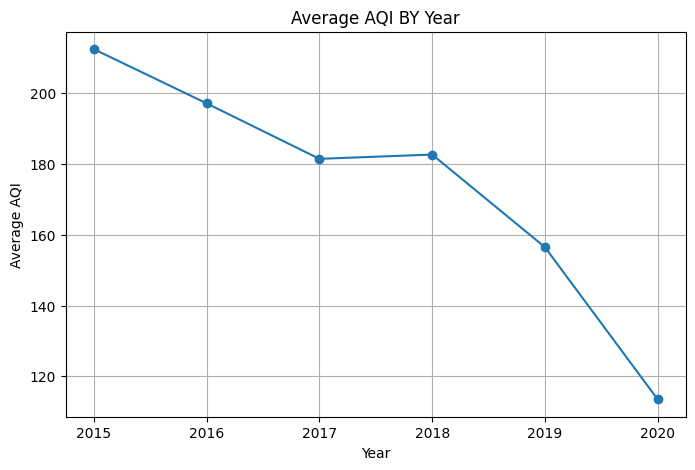

In [18]:
yearly_aqi.plot(kind="line" , marker="o", figsize=(8,5))
plt.title("Average AQI BY Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.show()

Rule
Situation	Best Chart
<!-- Year-wise trend	✅ Line Chart -->
<!-- Month-wise trend	✅ Line Chart -->
<!-- Daily trend	✅ Line Chart -->
<!-- City comparison	✅ Bar Chart -->
<!-- Pollutant comparison	✅ Bar Chart -->
<!-- Category percentage	✅ Pie Chart -->
<!-- Relationship between two numerical features	✅ Scatter Plot -->

"The x-axis represents time (Year), and my objective is to analyze how AQI changes over time. A line chart clearly highlights increasing or decreasing trends, making it more suitable than a bar chart for time-series data."

In [19]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"



In [20]:
df["Season"] = df["Month"].apply(get_season)
df[["Month", "Season"]].head(10)

,Month,Season
28,1,Winter
29,1,Winter
30,1,Winter
31,2,Winter
32,2,Winter
33,2,Winter
34,2,Winter
35,2,Winter
36,2,Winter
37,2,Winter


In [21]:
df["City"].unique()
df["City"].value_counts()

City
Delhi                 1999
Bengaluru             1910
Lucknow               1893
Chennai               1884
Hyderabad             1880
Patna                 1459
Gurugram              1453
Ahmedabad             1334
Visakhapatnam         1171
Amritsar              1126
Jaipur                1094
Thiruvananthapuram    1052
Amaravati              841
Mumbai                 775
Jorapokhar             771
Kolkata                754
Brajrajnagar           713
Talcher                698
Guwahati               495
Coimbatore             344
Chandigarh             299
Bhopal                 278
Shillong               205
Kochi                  158
Ernakulam              153
Aizawl                 111
Name: count, dtype: int64

In [22]:
x= df.drop(columns=["AQI" , "AQI_Bucket"])
y_reg = df["AQI"]
y_clf = df["AQI_Bucket"]

In [23]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_reg_train , y_reg_test ,  y_clf_train , y_clf_test = train_test_split(x , y_reg , y_clf , test_size = 0.2 , random_state = 42)

In [24]:
x_train = x_train.drop(columns=["Date"])
x_test = x_test.drop(columns=["Date"])

In [25]:
print(x_train.shape)
print(x_test.shape)

(19880, 15)
(4970, 15)


In [26]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore" , sparse_output=False)

In [27]:
city_train = encoder.fit_transform(x_train[["City"]])
city_test = encoder.fit_transform(x_test[["City"]])

In [28]:
print(city_train.shape)
print(city_test.shape)

(19880, 26)
(4970, 26)


In [29]:
print(encoder.get_feature_names_out())

['City_Ahmedabad' 'City_Aizawl' 'City_Amaravati' 'City_Amritsar'
 'City_Bengaluru' 'City_Bhopal' 'City_Brajrajnagar' 'City_Chandigarh'
 'City_Chennai' 'City_Coimbatore' 'City_Delhi' 'City_Ernakulam'
 'City_Gurugram' 'City_Guwahati' 'City_Hyderabad' 'City_Jaipur'
 'City_Jorapokhar' 'City_Kochi' 'City_Kolkata' 'City_Lucknow'
 'City_Mumbai' 'City_Patna' 'City_Shillong' 'City_Talcher'
 'City_Thiruvananthapuram' 'City_Visakhapatnam']


In [30]:
print(x_train["City"].iloc[0])
print(city_train[0])


Amaravati
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [31]:
city = x_train["City"].iloc[0]

print("Actual City:", city)

print("Encoded City:", city_train[0])

print("Active Column:",
      encoder.get_feature_names_out()[city_train[0].argmax()])

Actual City: Amaravati
Encoded City: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
Active Column: City_Amaravati


In [32]:
city_columns = encoder.get_feature_names_out()

In [33]:
city_train_df = pd.DataFrame(
    city_train,
    columns=city_columns,
    index=x_train.index
)

city_test_df = pd.DataFrame(
    city_test ,
    columns=city_columns,
    index = x_test.index
)

In [34]:
x_train = x_train.drop(columns=["City"])
x_test = x_test.drop(columns=["City"])

In [35]:
x_train = pd.concat([x_train , city_train_df] , axis=1)
x_test  = pd.concat([x_test , city_test_df], axis=1)

In [36]:
print(x_train.shape)
print(x_test.shape)

(19880, 40)
(4970, 40)


In [37]:
season_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [38]:
season_train = season_encoder.fit_transform(
    x_train[["Season"]]
)

In [39]:
season_test = season_encoder.transform(
    x_test[["Season"]]
)

In [40]:
print(season_encoder.get_feature_names_out())

['Season_Monsoon' 'Season_Post-Monsoon' 'Season_Summer' 'Season_Winter']


In [41]:
print(season_train.shape)
print(season_test.shape)

(19880, 4)
(4970, 4)


In [42]:
season_columns = season_encoder.get_feature_names_out()

season_train_df = pd.DataFrame(
    season_train,
    columns=season_columns,
    index = x_train.index
)

season_test_df = pd.DataFrame(
     season_train,
        columns=season_columns,
        index = x_train.index
)

In [43]:
x_train = x_train.drop(columns=["Season"])
x_test = x_test.drop(columns=["Season"])

In [44]:
x_train = pd.concat([x_train , season_train_df] , axis=1)
X_test = pd.concat([x_test, season_test_df], axis=1)

print(x_train.shape)
print(x_test.shape)

(19880, 43)
(4970, 39)


In [45]:
print("Train columns:", len(x_train.columns))
print("Test columns:", len(X_test.columns))

print("Columns in train but not test:")
print(set(x_train.columns) - set(X_test.columns))

print("Columns in test but not train:")
print(set(X_test.columns) - set(x_train.columns))

print(x_train.dtypes)
print(x_train.select_dtypes(include="object").columns)

Train columns: 43
Test columns: 43
Columns in train but not test:
set()
Columns in test but not train:
set()
PM2.5                      float64
PM10                       float64
NO                         float64
NO2                        float64
NOx                        float64
NH3                        float64
CO                         float64
SO2                        float64
O3                         float64
Benzene                    float64
Toluene                    float64
Year                         int32
Month                        int32
City_Ahmedabad             float64
City_Aizawl                float64
City_Amaravati             float64
City_Amritsar              float64
City_Bengaluru             float64
City_Bhopal                float64
City_Brajrajnagar          float64
City_Chandigarh            float64
City_Chennai               float64
City_Coimbatore            float64
City_Delhi                 float64
City_Ernakulam             float64
City_Gurugram   

In [46]:
print(df[["City" , "Date" , "PM2.5"]].head(10))
print(df["Date"].min())
print(df["Date"].max())

print(df.groupby("City")["Date"].nunique().describe())

         City       Date   PM2.5
28  Ahmedabad 2015-01-29   83.13
29  Ahmedabad 2015-01-30   79.84
30  Ahmedabad 2015-01-31   94.52
31  Ahmedabad 2015-02-01  135.99
32  Ahmedabad 2015-02-02  178.33
33  Ahmedabad 2015-02-03  139.70
34  Ahmedabad 2015-02-04   80.65
35  Ahmedabad 2015-02-05   58.36
36  Ahmedabad 2015-02-06   79.29
37  Ahmedabad 2015-02-07   88.70
2015-01-01 00:00:00
2020-07-01 00:00:00
count      26.000000
mean      955.769231
std       620.381967
min       111.000000
25%       381.750000
50%       808.000000
75%      1423.250000
max      1999.000000
Name: Date, dtype: float64


In [47]:
df= df.sort_values(["City" , "Date"]).reset_index(drop=True)

print(df[["City" , "Date" , "PM2.5"]].head(10))

        City       Date   PM2.5
0  Ahmedabad 2015-01-29   83.13
1  Ahmedabad 2015-01-30   79.84
2  Ahmedabad 2015-01-31   94.52
3  Ahmedabad 2015-02-01  135.99
4  Ahmedabad 2015-02-02  178.33
5  Ahmedabad 2015-02-03  139.70
6  Ahmedabad 2015-02-04   80.65
7  Ahmedabad 2015-02-05   58.36
8  Ahmedabad 2015-02-06   79.29
9  Ahmedabad 2015-02-07   88.70


In [48]:
df["PM2.5_lag1"] = df.groupby("City")["PM2.5"].shift(1)
df[["City" , "Date" , "PM2.5" , "PM2.5_lag1"]].head(10)
df["PM2.5_lag1"].isnull().sum()

np.int64(26)

In [49]:
df[df["PM2.5_lag1"].isnull()]["City"].nunique()
df[df["PM2.5_lag1"].isnull()]["City"].tolist()

['Ahmedabad',
 'Aizawl',
 'Amaravati',
 'Amritsar',
 'Bengaluru',
 'Bhopal',
 'Brajrajnagar',
 'Chandigarh',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Ernakulam',
 'Gurugram',
 'Guwahati',
 'Hyderabad',
 'Jaipur',
 'Jorapokhar',
 'Kochi',
 'Kolkata',
 'Lucknow',
 'Mumbai',
 'Patna',
 'Shillong',
 'Talcher',
 'Thiruvananthapuram',
 'Visakhapatnam']

In [50]:
df=df.dropna(subset=["PM2.5_lag1"]).reset_index(drop=True)
print(df.shape)
print(df["PM2.5_lag1"].isnull().sum())

(24824, 19)
0


In [51]:
df["PM2.5_rolling3"] = (
    df.groupby("City")["PM2.5"]
    .transform(lambda x: x.shift(1).rolling(window=3).mean())
)

df[["City" , "Date" , "PM2.5" , "PM2.5_lag1" , "PM2.5_rolling3"]].head(10)

,City,Date,PM2.5,PM2.5_lag1,PM2.5_rolling3
0,Ahmedabad,2015-01-30,79.84,83.13,NaN
1,Ahmedabad,2015-01-31,94.52,79.84,NaN
2,Ahmedabad,2015-02-01,135.99,94.52,NaN
3,Ahmedabad,2015-02-02,178.33,135.99,103.450000
4,Ahmedabad,2015-02-03,139.70,178.33,136.280000
5,Ahmedabad,2015-02-04,80.65,139.70,151.340000
6,Ahmedabad,2015-02-05,58.36,80.65,132.893333
7,Ahmedabad,2015-02-06,79.29,58.36,92.903333
8,Ahmedabad,2015-02-07,88.70,79.29,72.766667
9,Ahmedabad,2015-02-08,74.28,88.70,75.450000


Rolling average itself doesn't make the prediction "accurate."
It gives the model recent pollution trend information, which may improve prediction if that recent trend is predictive of today's AQI.

In [52]:
df["PM2.5_rolling3"].isnull().sum()

np.int64(78)

In [53]:
df= df.dropna(subset=["PM2.5_rolling3"]).reset_index(drop=True)
print(df.shape)
print(df["PM2.5_rolling3"].isnull().sum())

(24746, 20)
0


In [54]:
x=df.drop(columns=["AQI" , "AQI_Bucket"])
y_reg= df["AQI"]
y_clf= df["AQI_Bucket"]

print(df["Date"].min())
print(df["Date"].max())

print(df["Year"].value_counts().sort_index())

2015-01-05 00:00:00
2020-07-01 00:00:00
Year
2015    1799
2016    2565
2017    3210
2018    5712
2019    7051
2020    4409
Name: count, dtype: int64


In [55]:
train_df = df[df["Year"] < 2020 ].copy()
test_df = df[df["Year"] == 2020].copy()

print("Train:" , train_df.shape)
print("Test:" , test_df.shape)

Train: (20337, 20)
Test: (4409, 20)


In [56]:
x_train = train_df.drop(columns=["AQI" , "AQI_Bucket" , "Date"])
x_test = test_df.drop(columns=["AQI" , "AQI_Bucket" , "Date"])

y_reg_train = train_df["AQI"]
y_reg_test = test_df["AQI"]

y_clf_train = train_df["AQI_Bucket"]
y_clf_test = test_df["AQI_Bucket"]

print(x_train.select_dtypes(include=["object" , "string" , "category"]).columns)

Index(['City', 'Season'], dtype='str')


In [57]:
from sklearn.preprocessing import OneHotEncoder

city_encoder = OneHotEncoder(
    handle_unknown = "ignore",
    sparse_output=False
)

In [58]:
city_train = city_encoder.fit_transform(x_train[["City"]])
city_test = city_encoder.transform(x_test[["City"]])

print(city_train.shape)
print(city_test.shape)

print(city_encoder.get_feature_names_out())

(20337, 23)
(4409, 23)
['City_Ahmedabad' 'City_Amaravati' 'City_Amritsar' 'City_Bengaluru'
 'City_Bhopal' 'City_Brajrajnagar' 'City_Chandigarh' 'City_Chennai'
 'City_Coimbatore' 'City_Delhi' 'City_Gurugram' 'City_Guwahati'
 'City_Hyderabad' 'City_Jaipur' 'City_Jorapokhar' 'City_Kolkata'
 'City_Lucknow' 'City_Mumbai' 'City_Patna' 'City_Shillong' 'City_Talcher'
 'City_Thiruvananthapuram' 'City_Visakhapatnam']


In [59]:
print("Train cities:")
print(sorted(x_train["City"].unique()))

print("\n Test-only cities:")
print(sorted(set(x_test["City"].unique()) - set(x_train["City"].unique())))

Train cities:
['Ahmedabad', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

 Test-only cities:
['Aizawl', 'Ernakulam', 'Kochi']


In [60]:
season_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

season_train = season_encoder.fit_transform(
    x_train[["Season"]]
)

season_test = season_encoder.transform(
    x_test[["Season"]]
)
print(season_train)
print(season_test)
print(season_encoder.get_feature_names_out())

[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 ...
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
['Season_Monsoon' 'Season_Post-Monsoon' 'Season_Summer' 'Season_Winter']


Why did you use One-Hot Encoding for Season?
Season is a nominal categorical feature without a meaningful numerical ordering, so I used One-Hot Encoding instead of assigning arbitrary numeric labels.

Why sparse_output=False?
The dataset has only four season categories and 26 city categories, so the encoded feature space is small. I used dense output because it is easier to inspect and integrate with pandas, while sparse representation would be more useful for very high-cardinality categorical features.

In [61]:
city_columns  = city_encoder.get_feature_names_out()

city_train_df = pd.DataFrame(
    city_train,
    columns= city_columns,
    index = x_train.index
)

city_test_df = pd.DataFrame(
    city_test ,
    columns = city_columns,
    index = x_test.index
)


season_columns = season_encoder.get_feature_names_out()

season_train_df = pd.DataFrame(
    season_train,
    columns= season_columns,
    index= x_train.index
)

season_test_df = pd.DataFrame(
    season_test ,
    columns = season_columns ,
    index = x_test.index
)

x_train  = pd.concat(
    [x_train , city_train_df , season_train_df] ,
    axis = 1
)

x_test = pd.concat(
    [x_test , city_test_df , season_test_df],
    axis=1
)

print(x_train.shape)
print(x_test.shape)


(20337, 44)
(4409, 44)


In [82]:
x_train = x_train.drop(columns=["City", "Season"])
x_test = x_test.drop(columns=["City", "Season"])

In [83]:
print("X_train" , x_train.shape)
print("X_test:" , x_test.shape)
print("y_train:" , y_reg_train.shape)
print("y_test:" , y_reg_test.shape)

X_train (20337, 42)
X_test: (4409, 42)
y_train: (20337,)
y_test: (4409,)


In [84]:
print("Missing Values in x_train:" , x_train.isnull().sum().sum()) 
print("Missing in x_test:" , x_test.isnull().sum().sum())

Missing Values in x_train: 0
Missing in x_test: 0


In [85]:
print(x_train.dtypes.value_counts())
print(x_train.select_dtypes(include=["object" , "string" , "category"]).columns)

float64    40
int32       2
Name: count, dtype: int64
Index([], dtype='str')


In [88]:
y_pred_lr = lr_model.predict(x_test)

In [91]:
city_encoder = OneHotEncoder(drop="first" ,
              handle_unknown="ignore",
              sparse_output=False
              )

season_encoder =  OneHotEncoder(drop="first" ,
              handle_unknown="ignore",
              sparse_output=False
              )

In [95]:
city_train = city_encoder.fit_transform(train_df[["City"]])
city_test = city_encoder.transform(test_df[["City"]])

season_train = season_encoder.fit_transform(train_df[["Season"]])
season_test = season_encoder.transform(test_df[["Season"]])

c:\Users\yash1\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [97]:
print("City:" , city_train.shape , city_test.shape)
print("Season:" , season_train.shape, season_test.shape)

City: (20337, 22) (4409, 22)
Season: (20337, 3) (4409, 3)


In [99]:
city_columns = city_encoder.get_feature_names_out()

city_train_df = pd.DataFrame(
    city_train,
    columns= city_columns,
    index = train_df.index
)

city_test_df = pd.DataFrame(
    city_test,
    columns=city_columns,
    index = test_df.index
)

# for season

season_columns = season_encoder.get_feature_names_out()

season_train_df = pd.DataFrame(
    season_train,
    columns = season_columns,
    index = train_df.index
)

season_test_df = pd.DataFrame(
    season_test , 
    columns= season_columns,
    index = test_df.index
)

In [101]:
x_train = train_df.drop(columns=["AQI" , "AQI_Bucket" , "Date", "City" , "Season"])
x_test = test_df.drop(columns=["AQI" , "AQI_Bucket" , "Date", "City" , "Season"])

In [102]:
y_reg_train = train_df["AQI"]
y_reg_test = test_df["AQI"]

In [104]:
x_train = pd.concat(
    [x_train , city_train_df , season_train_df] ,
    axis = 1 
)

x_test = pd.concat(
    [x_test , city_test_df , season_test_df] ,
    axis= 1
)

In [107]:
print("x_train" , x_train.shape)
print("x_test" , x_test.shape)

print("Missing train:" , x_train.isnull().sum().sum())
print("Missing test:" , x_test.isnull().sum().sum())

print("Categorical:" ,
      x_train.select_dtypes(include=["object" , "string" , "category"]).columns)

x_train (20337, 40)
x_test (4409, 40)
Missing train: 0
Missing test: 0
Categorical: Index([], dtype='str')


In [108]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

lr_model.fit(x_train , y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](40,)","[ 0.63, 0.28,-0.22,...,12.09, 7.54, 7.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](40,)","['PM2.5','PM10','NO',...,'Season_Post-Monsoon','Season_Summer', 'Season_Winter']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,377.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,40
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,40


In [110]:
y_pred_lr = lr_model.predict(x_test)
print(y_pred_lr[:10])

[262.32644244 257.49086957 293.14981201 314.77864843 263.09692118
 267.53727705 304.16868452 232.44960671 213.82847548 210.62971552]


In [112]:
comparison = pd.DataFrame({
    "Actual_AQI": y_reg_test.values ,
    "Predicted_AQI" : y_pred_lr 
})

print(comparison.head(10))

   Actual_AQI  Predicted_AQI
0       216.0     262.326442
1       162.0     257.490870
2       220.0     293.149812
3       254.0     314.778648
4       255.0     263.096921
5       175.0     267.537277
6       285.0     304.168685
7       157.0     232.449607
8       129.0     213.828475
9       129.0     210.629716


In [113]:

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_reg_test , y_pred_lr)
rmse = root_mean_squared_error(y_reg_test , y_pred_lr)
r2 = r2_score(y_reg_test , y_pred_lr)

print("MAE:" , mae )
print("RMSE:" , rmse)
print("R2:" , r2)

MAE: 23.26460009520929
RMSE: 34.58638734486476
R2: 0.8284970386034518


In [116]:
from sklearn .ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state= 42 ,
    n_jobs =-1
)

In [119]:
rf_model.fit(x_train, y_reg_train)
y_pred_rf = rf_model.predict(x_test)

In [120]:
print(y_pred_rf[:10])

[182.88 184.52 349.58 355.53 270.97 346.96 222.74 147.03 130.76 119.75]


In [122]:
mae_rf = mean_absolute_error(y_reg_test , y_pred_rf)
rmse_rf = root_mean_squared_error(y_reg_test , y_pred_rf) 
r2_rf  = r2_score(y_reg_test, y_pred_rf)

print("Random forest MAE:" , mae_rf)
print("Random forest RMSE:", rmse_rf)
print("Random Forest R2:" , r2_rf)

Random forest MAE: 12.91098661828079
Random forest RMSE: 24.443712753447564
Random Forest R2: 0.9143365493079447


In [121]:
comparison = pd.DataFrame({
    "Actual_AQI": y_reg_test.values ,
    "Predicted_AQI" : y_pred_rf 
})

print(comparison.head(10))

   Actual_AQI  Predicted_AQI
0       216.0         182.88
1       162.0         184.52
2       220.0         349.58
3       254.0         355.53
4       255.0         270.97
5       175.0         346.96
6       285.0         222.74
7       157.0         147.03
8       129.0         130.76
9       129.0         119.75


✅ "Random Forest achieved an MAE of 12.91, RMSE of 24.44, and R² of 0.9143 on the 2020 temporal test set, substantially outperforming the Linear Regression baseline."

In [123]:
y_train_pred_rf = rf_model.predict(x_train)

train_r2_rf = r2_score(y_reg_train , y_train_pred_rf)
test_r2_rf = r2_score(y_reg_test , y_pred_rf)

print("Train R2:" , train_r2_rf)
print("Test R2:" , test_r2_rf)

Train R2: 0.9883895778330662
Test R2: 0.9143365493079447


In [126]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

PM2.5             0.430654
CO                0.371565
PM2.5_lag1        0.067429
NO                0.038237
PM10              0.031995
O3                0.010367
NOx               0.009116
SO2               0.007301
NO2               0.006246
PM2.5_rolling3    0.005772
Toluene           0.004985
Benzene           0.003978
Year              0.003466
Month             0.003170
NH3               0.001593
dtype: float64


In [128]:
rf_tuned = RandomForestRegressor(
    n_estimators=100 ,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(x_train , y_reg_train)
y_pred_rf_tuned = rf_tuned.predict(x_test)

In [129]:
mae_rf_tuned = mean_absolute_error(y_reg_test, y_pred_rf_tuned)
rmse_rf_tuned = root_mean_squared_error(y_reg_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_reg_test, y_pred_rf_tuned)

print("Tuned RF MAE :", mae_rf_tuned)
print("Tuned RF RMSE:", rmse_rf_tuned)
print("Tuned RF R²  :", r2_rf_tuned)

Tuned RF MAE : 12.655870461369346
Tuned RF RMSE: 23.42203955674953
Tuned RF R²  : 0.9213478422132064


In [130]:
y_train_pred_tuned = rf_tuned.predict(x_train)

print("Train R²:", r2_score(y_reg_train, y_train_pred_tuned))
print("Test R² :", r2_rf_tuned)

Train R²: 0.9762833809571627
Test R² : 0.9213478422132064


In [131]:
print("Tuned RF MAE :", mean_absolute_error(y_reg_test, y_pred_rf_tuned))
print("Tuned RF RMSE:", root_mean_squared_error(y_reg_test, y_pred_rf_tuned))

Tuned RF MAE : 12.655870461369346
Tuned RF RMSE: 23.42203955674953


In [132]:
print(y_clf_train.value_counts())
print()
print(y_clf_train.value_counts(normalize=True)* 100)

AQI_Bucket
Moderate        7318
Satisfactory    6245
Poor            2487
Very Poor       2193
Severe          1291
Good             803
Name: count, dtype: int64

AQI_Bucket
Moderate        35.983675
Satisfactory    30.707577
Poor            12.228942
Very Poor       10.783301
Severe           6.348036
Good             3.948468
Name: proportion, dtype: float64
